In [15]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import time
from collections import OrderedDict

# Klein-Gordon方程参数 (修改为single soliton的参数设定)
a = 0.3  # Klein-Gordon方程系数
b = 1    # 非线性系数
c = 0.25 # 孤立子速度参数 (修改为0.25)
k = np.sqrt(a / (2 * (a**2 - c**2)))  # 波数参数 (注意公式修正)

nu = 0.1

In [16]:
def analytical_solution(t, x):
    """
    Klein-Gordon方程精确解 (single soliton形式)
    u(x,t) = sqrt(2a/b) * sech(k(x - c*t))
    """
    sech_term = 1.0 / torch.cosh(k * (x - c * t))
    u = torch.sqrt(torch.tensor(2*a/b)) * sech_term
    return u.reshape(-1, 1)

def analytical_solution_v(t, x):
    """
    v = du/dt 的精确解
    v(x,t) = c * k * sqrt(2a/b) * sech(k(x - c*t)) * tanh(k(x - c*t))
    """
    sech_term = 1.0 / torch.cosh(k * (x - c * t))
    tanh_term = torch.tanh(k * (x - c * t))
    v = c * k * torch.sqrt(torch.tensor(2*a/b)) * sech_term * tanh_term
    return v.reshape(-1, 1)

def initial_condition_u(x):
    """初始条件 u(x,0) = sqrt(2a/b) * sech(kx)"""
    sech_term = 1.0 / torch.cosh(k * x)
    return torch.sqrt(torch.tensor(2*a/b)) * sech_term

def initial_condition_v(x):
    """初始条件 v(x,0) = c * k * sqrt(2a/b) * sech(kx) * tanh(kx)"""
    sech_term = 1.0 / torch.cosh(k * x)
    tanh_term = torch.tanh(k * x)
    return c * k * torch.sqrt(torch.tensor(2*a/b)) * sech_term * tanh_term

In [17]:
class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 2)  # 输出2个变量：u和v
        self.tanh = nn.Tanh()
        self.iter = 0

    def forward(self, x, t=None):
        if t is not None:
            # 分开的x和t作为输入
            inputs = torch.cat([t, x], dim=1)  # 注意顺序是[t,x]
        else:
            # 已经组合的输入
            inputs = x
            
        out = self.linear1(inputs)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        out = self.tanh(out)
        out = self.output(out)
        return out  # 返回[u, v]

In [18]:
# 从sampling_PDE.py引入的DNN类
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

# MMPDE采样类
class sampling_MMPDE():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        # 边界条件
        self.lb = torch.tensor(lb).float()
        self.ub = torch.tensor(ub).float()

        # 数据
        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float()
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float()
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        # 深度神经网络
        self.dnn = DNN(layers)

        # 优化器设置
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, u, t, x):

        # 计算u对t的一阶导数
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对t的二阶导数(utt)
        u_tt = torch.autograd.grad(
            u_t, t,
            grad_outputs=torch.ones_like(u_t),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对x的一阶导数
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对x的二阶导数(uxx)
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # w = (1 + u_xx ** 2 + u_tt ** 2) ** (1 / 2)
        # w = (1 + (0.3 * u_xx ** 2) + (0.4 * u_tt ** 2)) ** (1 / 2)
        # w = (1 + u_t ** 2 - a **2 * u_x ** 2 + a * u ** 2 - b/2 * u ** 4) ** (1 / 2)
        w = (1 + u_x ** 2) ** (1 / 2)  
        
        return w

    def net_sample(self, t, x):
        # 生成新的采样点
        xNew = self.dnn(torch.cat([t, x], dim=1))
        g0 = x - self.lb[1]
        g1 = x - self.ub[1]
        xNew = g0*g1*xNew + x
        return xNew

    def net_f(self, t, x):
        # 计算MMPDE方程的残差
        xNew = self.net_sample(t, x)

        xNew_t = torch.autograd.grad(
            xNew, t,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]

        xNew_x = torch.autograd.grad(
            xNew, x,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]
        
        xNew_xx = torch.autograd.grad(
            xNew_x, x,
            grad_outputs=torch.ones_like(xNew_x),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算解及其导数
        u = self.fun(torch.cat([t, x], dim=1))
        
        # 直接调用修改后的monitor函数，传入u,t,x
        G = self.monitor(u, t, x)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # 不再需要G_tx的计算，因为我们已经在monitor函数中处理了二阶导数

        E = G_x * xNew_x + G * xNew_xx
        f = xNew_t*self.nu*(G**2)*(xNew_x**2) + E

        return f

    def loss_func(self):
        # 计算损失函数
        f_pred = self.net_f(self.t_f, self.x_f)
        loss_f = torch.mean(f_pred ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        # 损失函数初始化
        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        # 训练过程
        print("开始MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('MMPDE_LBGFS 完成!')

        # 返回新的采样点
        new_x = self.net_sample(self.t_f, self.x_f)
        new_sample = torch.cat([self.t_f, new_x], dim=1)
        return new_sample

In [19]:
def create_simulation_function(model=None):
    """创建仿真函数，返回u和v的精确解"""
    def simulation_function(xt):
        t, x = xt[:, 0:1], xt[:, 1:2]
        u = analytical_solution(t, x)
        v = analytical_solution_v(t, x)
        return torch.cat([u, v], dim=1)
        
    return simulation_function

In [20]:
# 修改仿真域范围 (将时间域改为[0, 10])
lb = [0.0, -10.0]  # [t_min, x_min] 
ub = [10.0, 10.0]   # [t_max, x_max] - 时间域改为[0, 10]

# 生成均匀分布的采样点
num_samples_per_dim = int(np.sqrt(5000))  # 每个维度上采样约100个点
x_uniform = torch.linspace(-10, 10, num_samples_per_dim)  # x范围[-10,10]
t_uniform = torch.linspace(0, 10, num_samples_per_dim)   # t范围改为[0,10]

# 创建均匀网格
X_grid, T_grid = torch.meshgrid(x_uniform, t_uniform, indexing='ij')
x_init = X_grid.reshape(-1, 1)
t_init = T_grid.reshape(-1, 1)

# 合并为输入样本
X_f_init = torch.cat([t_init, x_init], dim=1).numpy()

# 创建模拟函数
sim_func = create_simulation_function()

# 定义MMPDE参数
mmpde_layers = [2, 20, 20, 20, 1]  # 输入(t,x)，输出新的x坐标
adam_iter = 5000
lbfgs_iter = 1000

# 创建MMPDE采样器并训练
mmpde_sampler = sampling_MMPDE(
    X_f=X_f_init,
    u_fun=sim_func,
    layers=mmpde_layers,
    lb=lb,
    ub=ub,
    nu=nu,
    AdamIter=adam_iter,
    LBFGSIter=lbfgs_iter
)

# 训练MMPDE并获取优化后的采样点
new_samples = mmpde_sampler.train()

# 提取优化后的采样点
t_colloc = new_samples[:, 0:1].clone().detach().requires_grad_(True)
x_colloc = new_samples[:, 1:2].clone().detach().requires_grad_(True)
x_colloc_combined = torch.cat([t_colloc, x_colloc], dim=1)

# 生成边界条件点（修改后的Neumann边界条件在x=-10和x=10处）
N_bc = 1000
t_bc = torch.rand(N_bc, 1) * (ub[0] - lb[0]) + lb[0]  # t ∈ [0, 10]
x_bc_left = torch.full((N_bc//2, 1), -10.0)  # x = -10
x_bc_right = torch.full((N_bc//2, 1), 10.0)  # x = 10
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc_split = torch.split(t_bc, N_bc//2)
x_bc_left_combined = torch.cat([t_bc_split[0], x_bc_left], dim=1)
x_bc_right_combined = torch.cat([t_bc_split[1], x_bc_right], dim=1)
x_bc_combined = torch.cat([x_bc_left_combined, x_bc_right_combined], dim=0)
x_bc_combined.requires_grad_(True)

# 初始条件点(t=0)
N_ic = 1000
x_ic = torch.rand(N_ic, 1) * 20 - 10  # x ∈ [-10, 10]
t_ic = torch.zeros(N_ic, 1)
x_ic_combined = torch.cat([t_ic, x_ic], dim=1)
x_ic_combined.requires_grad_(True)

开始MMPDE训练...
MMPDE_Adam Iter 100, Loss: 1.015962
Time: 1.2119s
MMPDE_Adam Iter 200, Loss: 0.528371
Time: 1.2111s
MMPDE_Adam Iter 300, Loss: 0.408603
Time: 1.1502s
MMPDE_Adam Iter 400, Loss: 0.343157
Time: 1.2271s
MMPDE_Adam Iter 500, Loss: 0.292398
Time: 1.1504s
MMPDE_Adam Iter 600, Loss: 0.249970
Time: 1.1263s
MMPDE_Adam Iter 700, Loss: 0.214110
Time: 1.1761s
MMPDE_Adam Iter 800, Loss: 0.183892
Time: 1.1272s
MMPDE_Adam Iter 900, Loss: 0.158615
Time: 1.1550s
MMPDE_Adam Iter 1000, Loss: 0.137660
Time: 1.1129s
MMPDE_Adam Iter 1100, Loss: 0.120446
Time: 1.1270s
MMPDE_Adam Iter 1200, Loss: 0.106425
Time: 1.1228s
MMPDE_Adam Iter 1300, Loss: 0.095085
Time: 1.1300s
MMPDE_Adam Iter 1400, Loss: 0.085955
Time: 1.1367s
MMPDE_Adam Iter 1500, Loss: 0.078610
Time: 1.1405s
MMPDE_Adam Iter 1600, Loss: 0.072680
Time: 1.0972s
MMPDE_Adam Iter 1700, Loss: 0.067853
Time: 1.1243s
MMPDE_Adam Iter 1800, Loss: 0.063874
Time: 1.1445s
MMPDE_Adam Iter 1900, Loss: 0.060538
Time: 1.1617s
MMPDE_Adam Iter 2000, Loss:

tensor([[ 0.0000,  2.4425],
        [ 0.0000,  7.5413],
        [ 0.0000, -1.9061],
        ...,
        [ 0.0000, -2.6196],
        [ 0.0000, -8.9113],
        [ 0.0000,  5.3119]], requires_grad=True)

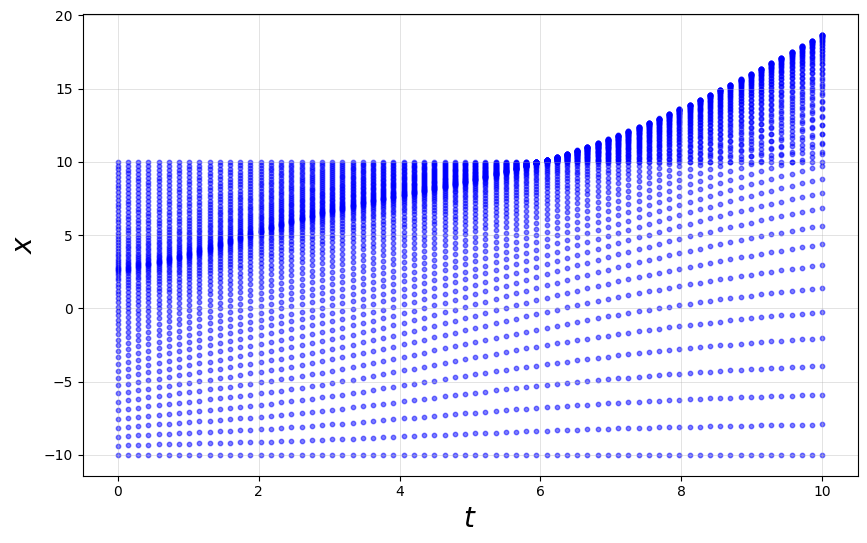

In [21]:
# 可视化采样点
plt.figure(figsize=(10, 6))
plt.scatter(t_colloc.detach().numpy(), x_colloc.detach().numpy(), color='blue', alpha=0.5, label='Collocation', s=10)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
plt.show()

In [22]:
def x_f_loss_fun(inputs, model):
    """
    计算Klein-Gordon方程PDE残差（一阶系统形式）:
    du/dt = v
    dv/dt = a^2 * u_xx - a * u + b * u^3
    """
    if not inputs.requires_grad:
        inputs = Variable(inputs, requires_grad=True)
    
    # 获取模型预测的u和v
    outputs = model(inputs)
    u = outputs[:, 0:1]  # 第一个输出是u
    v = outputs[:, 1:2]  # 第二个输出是v
    
    # 提取坐标
    t = inputs[:, 0:1]
    x = inputs[:, 1:2]
    
    # 计算u关于输入的梯度
    u_grad = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grad[:, 0:1]  # du/dt
    u_x = u_grad[:, 1:2]  # du/dx
    
    # 计算v关于输入的梯度
    v_grad = torch.autograd.grad(v, inputs, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_t = v_grad[:, 0:1]  # dv/dt
    
    # 计算u_xx - 对u_x再求一次关于x的导数
    u_xx = torch.autograd.grad(u_x, inputs, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]
    
    # 计算PDE残差
    # 第一个方程：du/dt = v
    f1 = u_t - v
    
    # 第二个方程：dv/dt = a^2 * u_xx - a * u + b * u^3
    f2 = v_t - (a**2 * u_xx - a * u + b * (u**3))
    
    return torch.cat([f1, f2], dim=1)

In [23]:
def boundary_loss(model, x_bc):
    """
    边界条件损失：修改为single soliton的Neumann边界条件
    u_x(-10, t) = -sqrt(2a/b) * k * sech(k * (-10 - c * t)) * tanh(k * (-10 - c * t))
    u_x(10, t) = -sqrt(2a/b) * k * sech(k * (10 - c * t)) * tanh(k * (10 - c * t))
    """
    inputs = x_bc.clone().requires_grad_(True)
    outputs = model(inputs)
    u = outputs[:, 0:1]  # 获取u
    
    # 计算u_x
    u_x = torch.autograd.grad(
        u, inputs,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0][:, 1:2]  # 对x的导数
    
    # 提取时间和空间坐标
    t = inputs[:, 0:1]
    x = inputs[:, 1:2]
    
    # 计算理论边界条件值
    # 对于x=-10的点
    mask_left = (x == -10.0).float()
    sech_left = 1.0 / torch.cosh(k * (-10.0 - c * t))
    tanh_left = torch.tanh(k * (-10.0 - c * t))
    u_x_left_target = -torch.sqrt(torch.tensor(2*a/b)) * k * sech_left * tanh_left
    
    # 对于x=10的点  
    mask_right = (x == 10.0).float()
    sech_right = 1.0 / torch.cosh(k * (10.0 - c * t))
    tanh_right = torch.tanh(k * (10.0 - c * t))
    u_x_right_target = -torch.sqrt(torch.tensor(2*a/b)) * k * sech_right * tanh_right
    
    # 组合目标值
    u_x_target = mask_left * u_x_left_target + mask_right * u_x_right_target
    
    # 计算边界条件损失
    return torch.mean((u_x - u_x_target)**2)

def initial_condition_loss(model, x_ic):
    """
    初始条件损失：
    1. u(x,0) = sqrt(2a/b) * sech(kx)
    2. v(x,0) = c * k * sqrt(2a/b) * sech(kx) * tanh(kx)
    """
    outputs = model(x_ic)
    u_pred = outputs[:, 0:1]
    v_pred = outputs[:, 1:2]
    
    # 提取x坐标
    x = x_ic[:, 1:2]
    
    # 计算初始条件目标值
    u_ic_target = initial_condition_u(x)
    v_ic_target = initial_condition_v(x)
    
    # 计算损失
    u_loss = torch.mean((u_pred - u_ic_target)**2)
    v_loss = torch.mean((v_pred - v_ic_target)**2)
    
    return u_loss + v_loss

In [24]:
# 创建模型
model = PINN(2, 40)  # 输入维度是2 (t和x)，隐藏层维度40
model.iter = 0  # 添加迭代计数器

# 优化器参数
adam_iter = 5000  # Adam迭代次数
lbfgs_iter = 10000  # LBFGS迭代次数
adam_lr = 0.001  # Adam学习率
lbfgs_lr = 0.5  # LBFGS学习率

# 定义Adam优化器
optimizer_adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.5)

# 第一阶段：Adam优化
print("开始第一阶段: Adam优化...")
for epoch in range(adam_iter):
    optimizer_adam.zero_grad()
    
    # 计算PDE残差
    f = x_f_loss_fun(x_colloc_combined, model)
    loss_pde = torch.mean(f**2)
    
    # 计算边界条件损失
    loss_bc = boundary_loss(model, x_bc_combined)
    
    # 计算初始条件损失
    loss_ic = initial_condition_loss(model, x_ic_combined)
    
    # 总损失
    total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
    
    total_loss.backward()
    
    # 添加梯度裁剪
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer_adam.step()
    scheduler.step()
    model.iter += 1
    
    if epoch % 100 == 0:
        print(f"Epoch: {epoch}/{adam_iter}, "
              f"Loss: {total_loss.item():.6e}, "
              f"PDE: {loss_pde.item():.6e}, "
              f"BC: {loss_bc.item():.6e}, "
              f"IC: {loss_ic.item():.6e}")

# 定义LBFGS优化器
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), 
    lr=lbfgs_lr, 
    max_iter=20,
    max_eval=25,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    history_size=50,
    line_search_fn="strong_wolfe"
)

# 第二阶段：LBFGS优化
print("开始第二阶段: LBFGS优化...")

# 在训练循环中修改损失计算
def closure():
    optimizer_lbfgs.zero_grad()
    
    # 计算PDE残差
    f = x_f_loss_fun(x_colloc_combined, model)
    loss_pde = torch.mean(f**2)  # f现在是2列的矩阵
    
    # 计算边界条件损失
    loss_bc = boundary_loss(model, x_bc_combined)
    
    # 计算初始条件损失
    loss_ic = initial_condition_loss(model, x_ic_combined)
    
    # 总损失
    total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
    
    total_loss.backward()
    
    model.iter += 1
    if model.iter % 100 == 0:
        print(f"LBFGS Iter: {model.iter}, "
              f"Loss: {total_loss.item():.6e}, "
              f"PDE: {loss_pde.item():.6e}, "
              f"BC: {loss_bc.item():.6e}, "
              f"IC: {loss_ic.item():.6e}")
    
    return total_loss

# 运行LBFGS优化
for i in range(lbfgs_iter // 20):  # 由于max_iter设为20，我们在外层循环控制总迭代次数
    optimizer_lbfgs.step(closure)
    current_loss = closure()
    print(f"LBFGS外循环 {i+1}/{lbfgs_iter//20}, 当前损失: {current_loss.item():.6e}")

print("优化完成!")

开始第一阶段: Adam优化...
Epoch: 0/5000, Loss: 1.060765e+00, PDE: 3.072308e-03, BC: 1.253610e-04, IC: 1.056439e-01
Epoch: 100/5000, Loss: 2.327533e-02, PDE: 2.252822e-04, BC: 2.284056e-05, IC: 2.282164e-03
Epoch: 200/5000, Loss: 1.262047e-03, PDE: 1.532171e-04, BC: 5.826790e-07, IC: 1.103003e-04
Epoch: 300/5000, Loss: 3.796276e-04, PDE: 1.019191e-04, BC: 6.486443e-07, IC: 2.712221e-05
Epoch: 400/5000, Loss: 2.201364e-04, PDE: 8.584806e-05, BC: 4.932032e-07, IC: 1.293563e-05
Epoch: 500/5000, Loss: 1.566431e-04, PDE: 7.263881e-05, BC: 3.933215e-07, IC: 8.007110e-06
Epoch: 600/5000, Loss: 1.218052e-04, PDE: 6.141708e-05, BC: 3.112867e-07, IC: 5.727530e-06
Epoch: 700/5000, Loss: 1.024728e-04, PDE: 5.307399e-05, BC: 2.413360e-07, IC: 4.698549e-06
Epoch: 800/5000, Loss: 8.950490e-05, PDE: 4.572215e-05, BC: 1.859688e-07, IC: 4.192306e-06
Epoch: 900/5000, Loss: 1.545694e-04, PDE: 4.102299e-05, BC: 1.480122e-07, IC: 1.120663e-05
Epoch: 1000/5000, Loss: 2.167557e-03, PDE: 5.704165e-05, BC: 1.240997e-07,

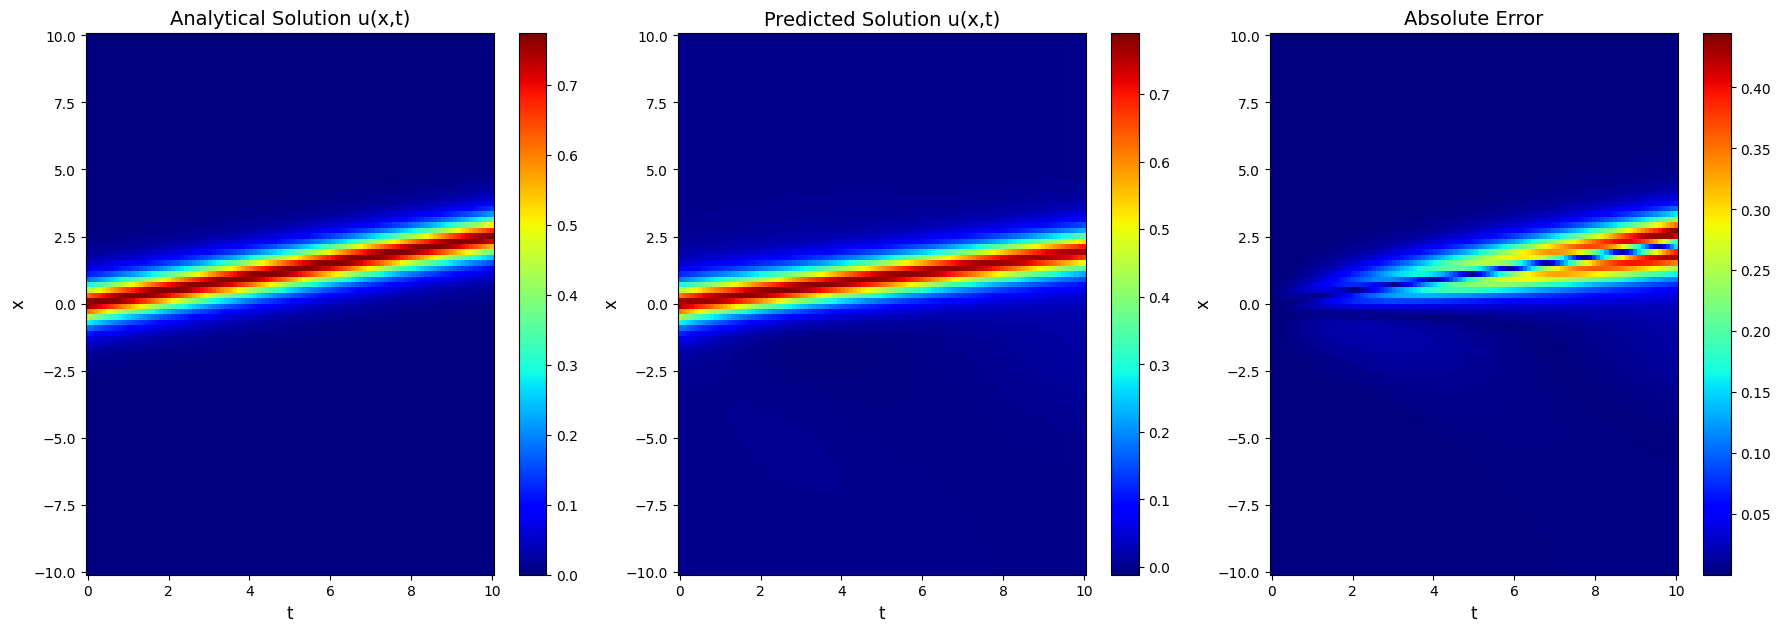

u的L2误差: 0.065146
v的L2误差: 0.038729


In [25]:
# 修改可视化部分 - 更新网格范围到[0, 10]
# 创建网格点
nx, nt = 100, 100
x = torch.linspace(-10, 10, nx).reshape(-1, 1)  # x范围[-10,10]
t = torch.linspace(0, 10, nt).reshape(-1, 1)   # t范围改为[0,10]

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

# 组合输入
X_test = torch.cat([T_flat, X_flat], dim=1)

# 模型预测
with torch.no_grad():
    outputs_pred = model(X_test)
    u_pred = outputs_pred[:, 0:1].reshape(nx, nt).detach().numpy()
    v_pred = outputs_pred[:, 1:2].reshape(nx, nt).detach().numpy()

# 解析解
u_exact = analytical_solution(T_flat, X_flat).reshape(nx, nt).detach().numpy()
v_exact = analytical_solution_v(T_flat, X_flat).reshape(nx, nt).detach().numpy()

# 计算误差
u_error = np.abs(u_pred - u_exact)
v_error = np.abs(v_pred - v_exact)

# 显示热图对比（现在显示u和v）
plt.figure(figsize=(18, 12))

# u的对比
plt.subplot(231)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_exact, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Analytical Solution u(x,t)', fontsize=14)

plt.subplot(232)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_pred, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Predicted Solution u(x,t)', fontsize=14)

plt.subplot(233)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_error, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Absolute Error', fontsize=14)

plt.tight_layout()
plt.show()

# 计算L2误差
total_u_l2_error = np.sqrt(np.mean(np.square(u_pred - u_exact)))
total_v_l2_error = np.sqrt(np.mean(np.square(v_pred - v_exact)))
print(f"u的L2误差: {total_u_l2_error:.6f}")
print(f"v的L2误差: {total_v_l2_error:.6f}")

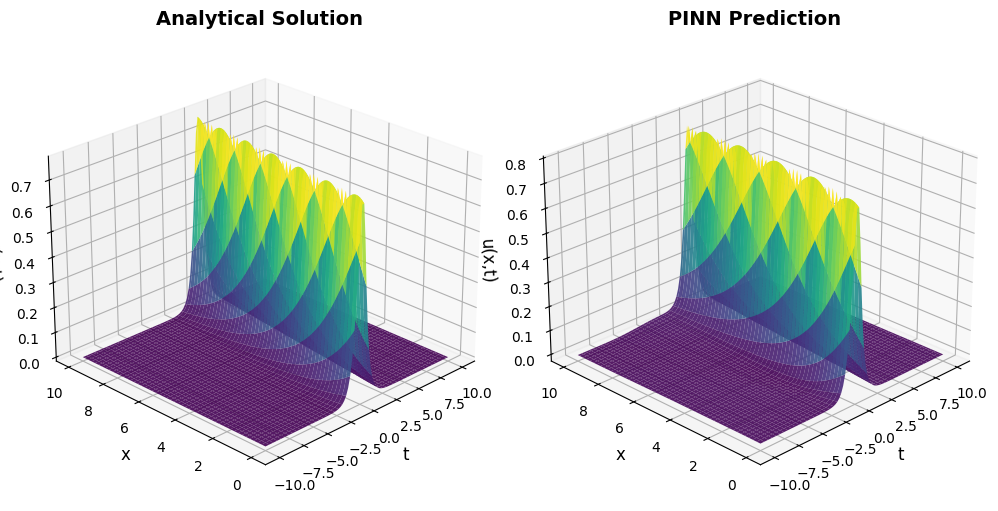

In [26]:
# 创建单独的大图显示u的三维对比
fig = plt.figure(figsize=(15, 5))

# 解析解
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf1 = ax1.plot_surface(X.numpy(), T.numpy(), u_exact, 
                        cmap='viridis', alpha=0.9, linewidth=0.5, 
                        antialiased=True, linestyle='--')
ax1.set_xlabel('t', fontsize=12)
ax1.set_ylabel('x', fontsize=12)
ax1.set_zlabel('u(x,t)', fontsize=12)
ax1.set_title('Analytical Solution', fontsize=14, fontweight='bold')
ax1.view_init(elev=25, azim=45)
# 移除colorbar

# 设置坐标轴反向
ax1.invert_xaxis()  # t轴反向：从12到0
ax1.invert_yaxis()  # x轴反向：从10到-10

# PINN预测解
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X.numpy(), T.numpy(), u_pred, 
                        cmap='viridis', alpha=0.9, linewidth=0.5, 
                        antialiased=True, linestyle='--')
ax2.set_xlabel('t', fontsize=12)
ax2.set_ylabel('x', fontsize=12)
ax2.set_zlabel('u(x,t)', fontsize=12)
ax2.set_title('PINN Prediction', fontsize=14, fontweight='bold')
ax2.view_init(elev=25, azim=45)
# 移除colorbar

# 设置坐标轴反向
ax2.invert_xaxis()  # t轴反向：从12到0
ax2.invert_yaxis()  # x轴反向：从10到-10

plt.tight_layout()
plt.show()

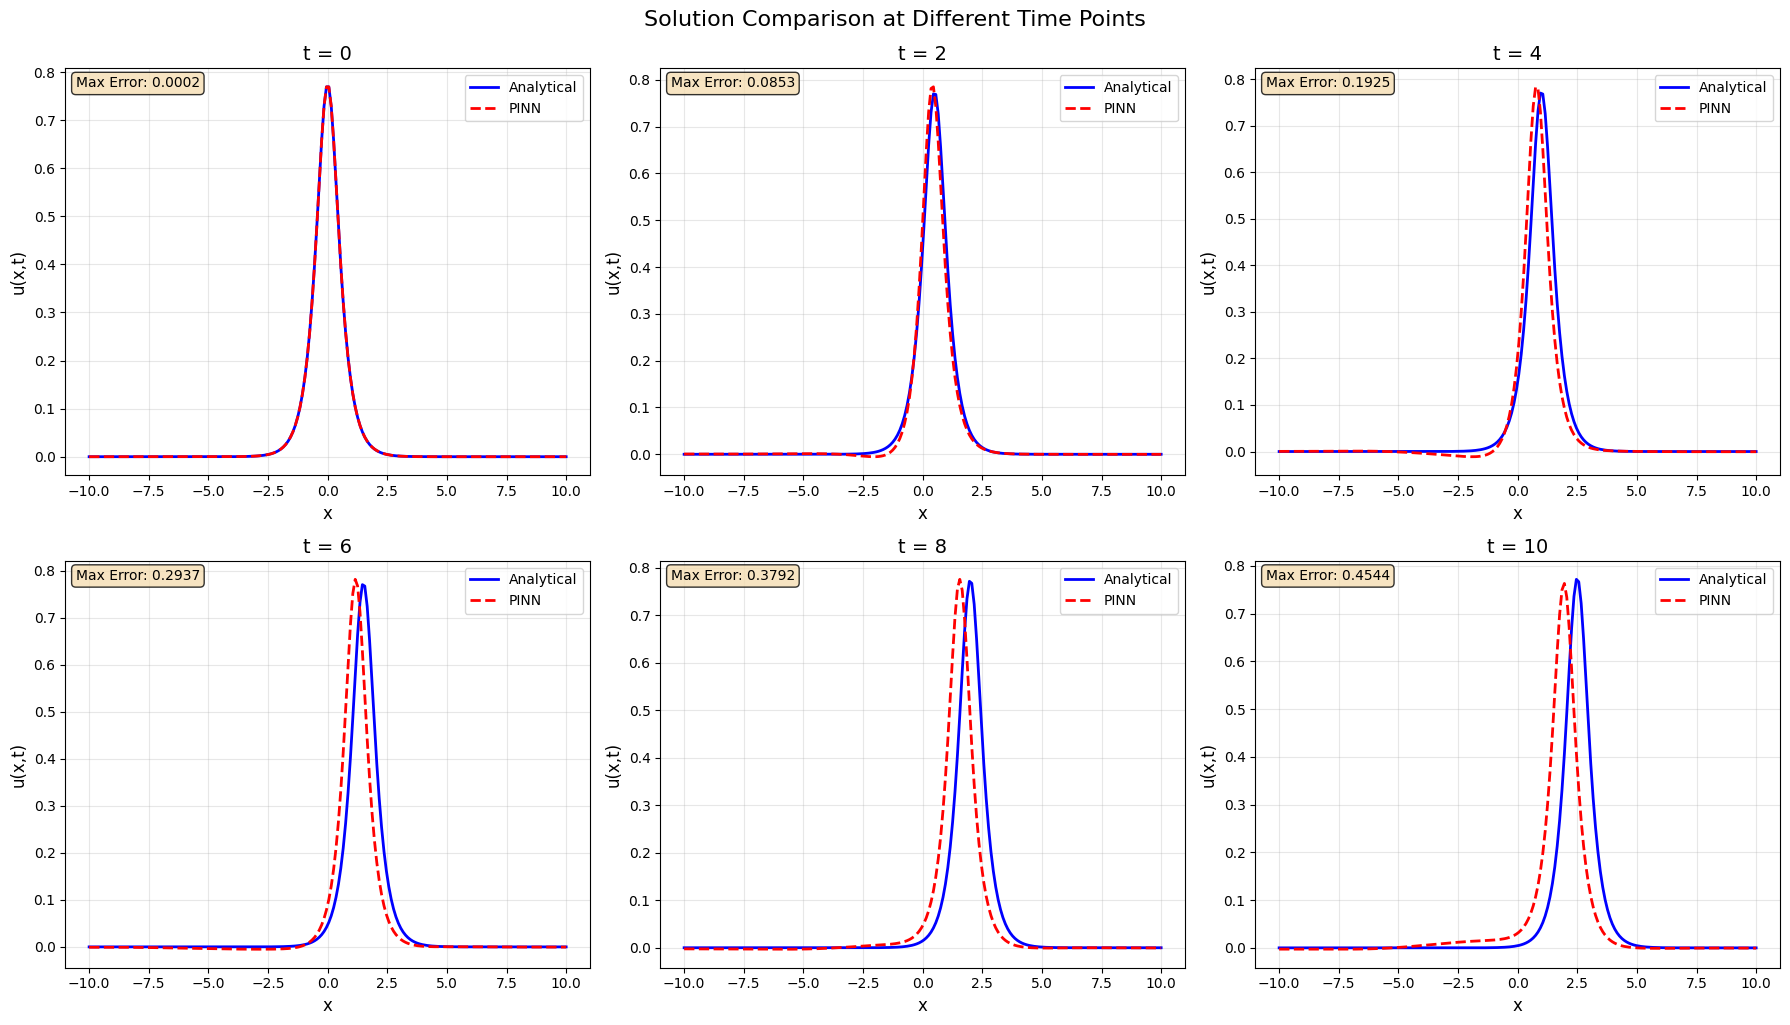

In [27]:
# 绘制特定时间切片的对比图 - 修改时间点
def plot_time_slices():
    """绘制不同时间点的解的切片对比"""
    time_points = [0, 2, 4, 6, 8, 10]  # 修改时间点为[0, 2, 4, 6, 8, 10]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    x_slice = torch.linspace(-10, 10, 200).reshape(-1, 1)
    
    for i, t_val in enumerate(time_points):
        if i >= 6:  # 只有6个子图
            break
            
        t_slice = torch.full_like(x_slice, t_val)
        x_test_slice = torch.cat([t_slice, x_slice], dim=1)
        
        # 模型预测
        with torch.no_grad():
            outputs_slice = model(x_test_slice)
            u_pred_slice = outputs_slice[:, 0:1].detach().numpy()
        
        # 解析解
        u_exact_slice = analytical_solution(t_slice, x_slice).detach().numpy()
        
        # 绘制对比
        axes[i].plot(x_slice.numpy(), u_exact_slice, 'b-', linewidth=2, label='Analytical')
        axes[i].plot(x_slice.numpy(), u_pred_slice, 'r--', linewidth=2, label='PINN')
        axes[i].set_xlabel('x', fontsize=12)
        axes[i].set_ylabel('u(x,t)', fontsize=12)
        axes[i].set_title(f't = {t_val}', fontsize=14)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
        
        # 计算该时间点的误差
        error_slice = np.abs(u_pred_slice - u_exact_slice)
        max_error = np.max(error_slice)
        axes[i].text(0.02, 0.98, f'Max Error: {max_error:.4f}', 
                    transform=axes[i].transAxes, fontsize=10,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.suptitle('Solution Comparison at Different Time Points', fontsize=16, y=1.02)
    plt.show()

# 调用函数绘制时间切片对比
plot_time_slices()

D:\TempFiles\ipykernel_38072\1005194064.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


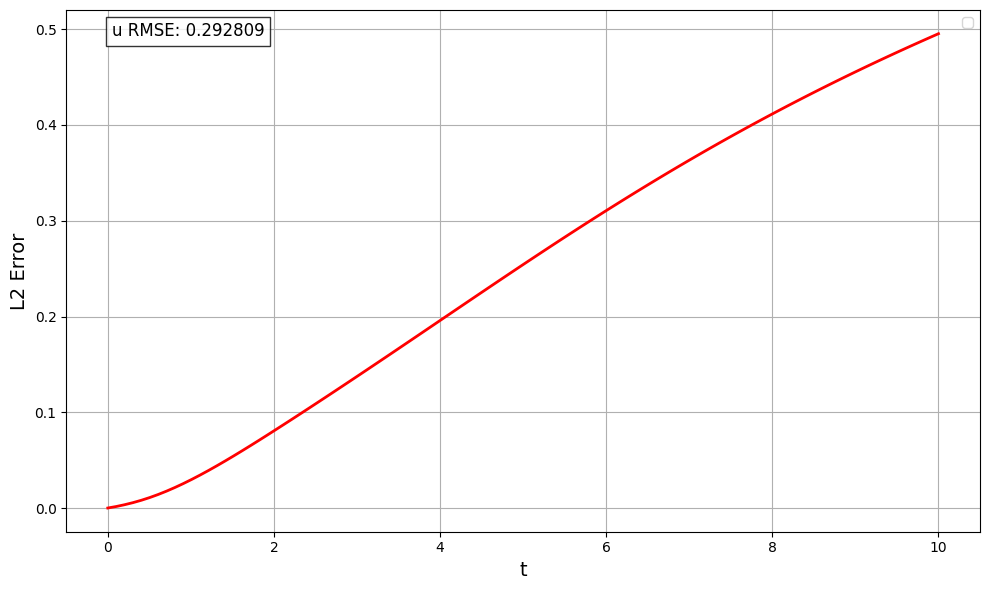

In [28]:
# 修改L2误差计算函数的x_range参数
def compute_and_plot_l2_error(u_analytical, u_predicted, t_points, x_range):
    """计算并绘制不同时间点上的L2误差"""
    # 计算空间步长(用于数值积分)
    dx = (x_range[1] - x_range[0]) / (u_analytical.shape[0] - 1)
    
    # 初始化L2误差数组
    l2_errors_u = np.zeros(len(t_points))
    
    # 对每个时间点计算L2误差
    for i in range(len(t_points)):
        # 计算u的L2误差
        squared_error_u = (u_analytical[:, i] - u_predicted[:, i])**2
        l2_errors_u[i] = np.sqrt(np.sum(squared_error_u) * dx)
    
    # 绘制L2误差随时间的变化
    plt.figure(figsize=(10, 6))
    plt.plot(t_points, l2_errors_u, 'r-', linewidth=2)
    plt.grid(True)
    plt.xlabel('t', fontsize=14)
    plt.ylabel('L2 Error', fontsize=14)
    plt.legend()
    
    # 添加均方根误差信息
    rmse_u = np.sqrt(np.mean(l2_errors_u**2))
    plt.text(0.05, 0.95, f'u RMSE: {rmse_u:.6f}', 
             transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return l2_errors_u

# 使用该函数计算并绘制L2误差
t_points = t.squeeze().numpy()  # 时间点数组
x_range = [-10, 10]  # 修改x的范围为[-10, 10]

# 计算并绘制L2误差
l2_errors_u = compute_and_plot_l2_error(
    u_analytical=u_exact, 
    u_predicted=u_pred,
    t_points=t_points,
    x_range=x_range
)